## Make a copy and use this colab to write your final project code. Good luck!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

my_data = pd.read_csv('/content/sample_data/Untitled Folder/movies.csv')

specific_genres = [
    'Action & Adventure', 'Documentaries', 'Horror Movies', 'Comedies',
    'Thrillers', 'Children & Family Movies', "Kids' TV", 'Sci-Fi & Fantasy',
    'Dramas', 'Romantic Movies', 'Fantasy',
    'TV Dramas', 'Crime TV Shows', 'International TV Shows', 'TV Action & Adventure',
    'Docuseries', 'Reality TV', 'TV Mysteries', 'British TV Shows', 'TV Comedies',
    'Spanish-Language TV Shows', 'TV Horror', 'TV Sci-Fi & Fantasy', 'Romantic TV Shows',
    'Anime Series', 'Korean TV Shows', 'Science & Nature TV', 'Teen TV Shows', 'TV Shows',
    'TV Thrillers', 'Classic & Cult TV', 'Stand-Up Comedy & Talk Shows'
]

df_genres_filtered = my_data[my_data['listed_in'].notna()].copy()
df_genres_filtered['genre'] = df_genres_filtered['listed_in'].str.split(', ')
df_genres_exploded = df_genres_filtered.explode('genre')
df_genres_exploded = df_genres_exploded[df_genres_exploded['genre'].isin(specific_genres)]
genre_counts_by_type = df_genres_exploded.groupby(['type', 'genre']).size().unstack(fill_value=0)

for genre in specific_genres:
    if genre not in genre_counts_by_type.columns:
        genre_counts_by_type[genre] = 0

genre_counts_by_type = genre_counts_by_type[specific_genres]

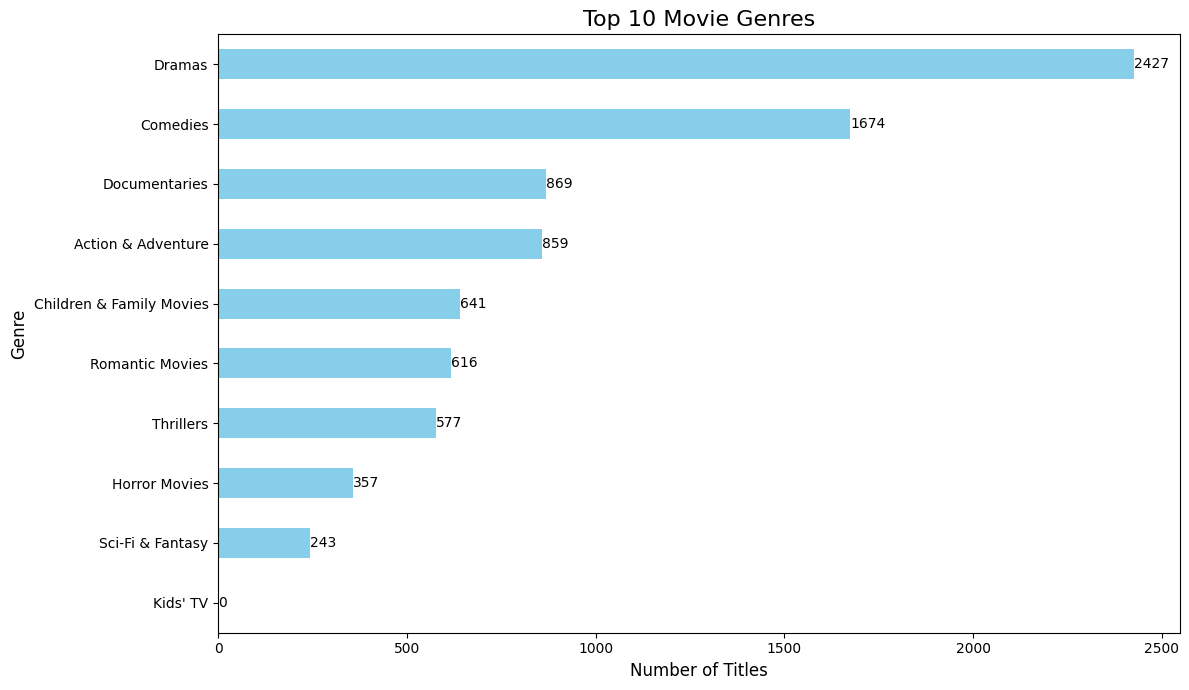

In [ ]:
# Graph 1: Top 10 Movie Genres (Horizontal Bar Chart)

movie_genres_counts = genre_counts_by_type.loc['Movie'].sort_values(ascending=False)

top_10_movie_genres = movie_genres_counts.head(10)

plt.figure(figsize=(12, 7))
ax = top_10_movie_genres.plot(kind='barh', color='skyblue')
plt.title('Top 10 Movie Genres', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xticks(rotation=0)
plt.gca().invert_yaxis()

for index, value in enumerate(top_10_movie_genres):
    ax.text(value, index, str(int(value)), ha='left', va='center')

plt.tight_layout()
plt.show()

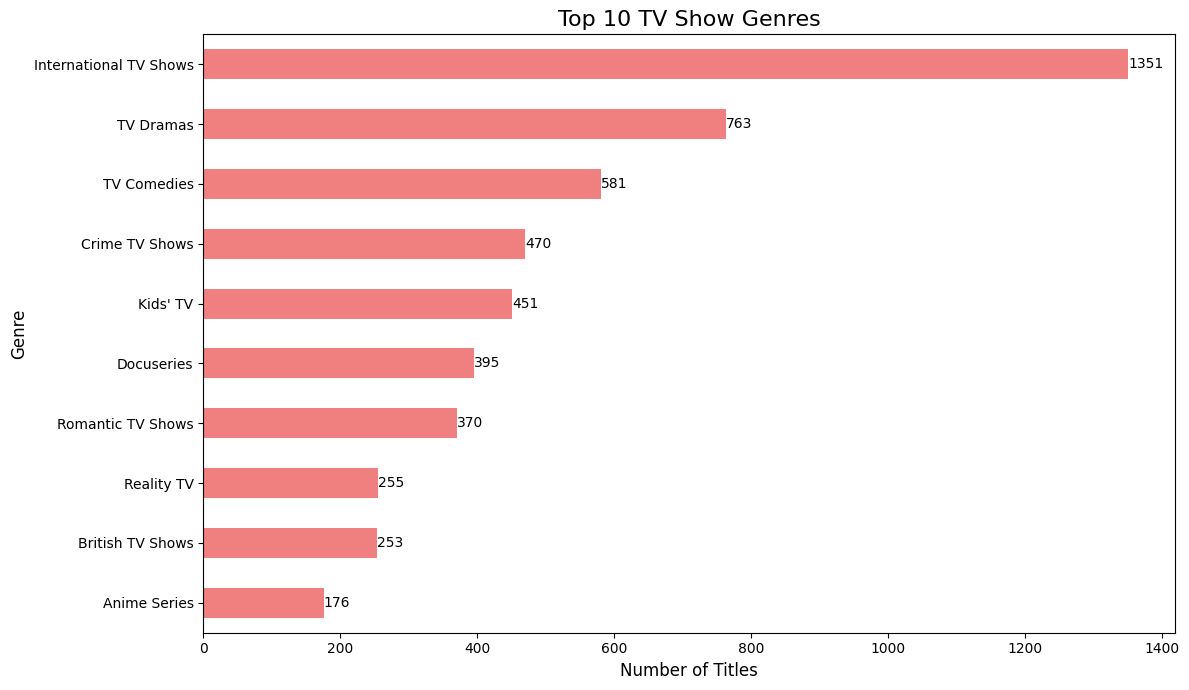

In [ ]:
# Graph 2: Top 10 TV Show Genres (Horizontal Bar Chart)

tv_show_genres_counts = genre_counts_by_type.loc['TV Show'].sort_values(ascending=False)

top_10_tv_show_genres = tv_show_genres_counts.head(10)

plt.figure(figsize=(12, 7))
ax = top_10_tv_show_genres.plot(kind='barh', color='lightcoral')
plt.title('Top 10 TV Show Genres', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xticks(rotation=0)
plt.gca().invert_yaxis()

for index, value in enumerate(top_10_tv_show_genres):
    ax.text(value, index, str(int(value)), ha='left', va='center')

plt.tight_layout()
plt.show()

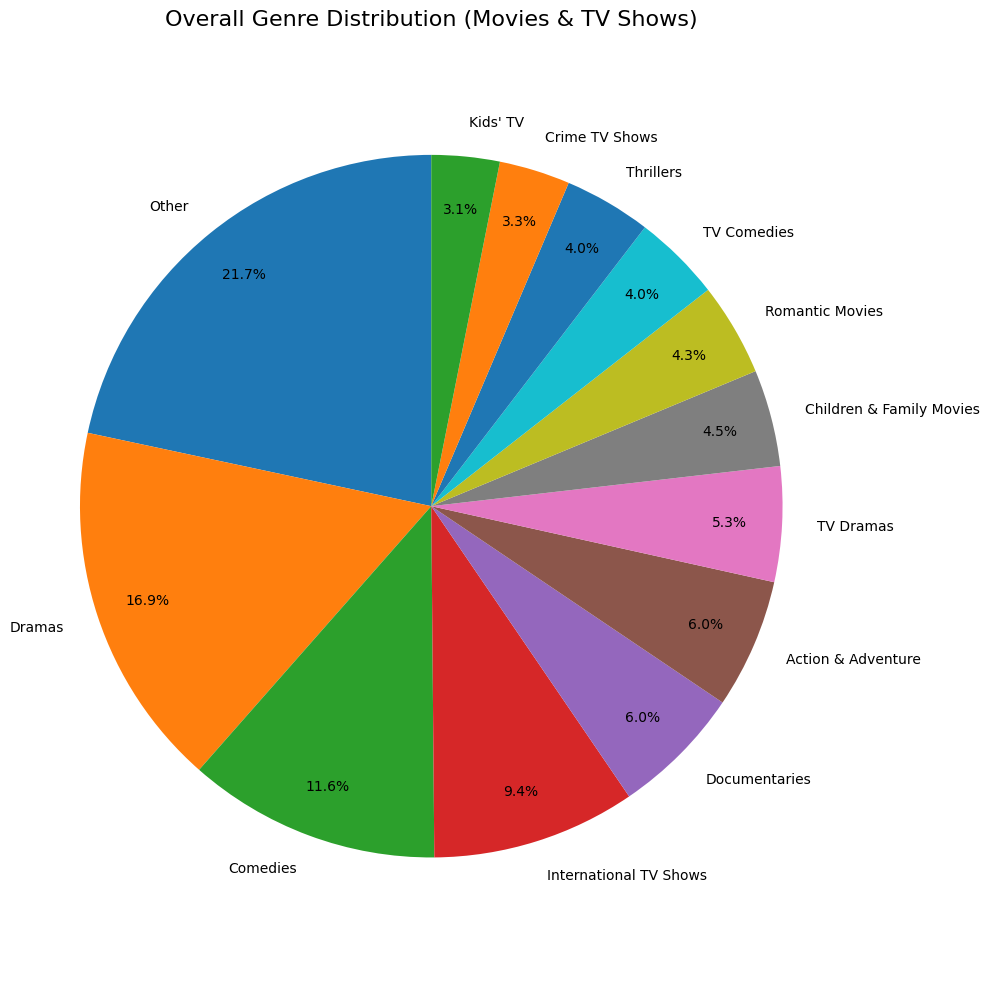

In [ ]:
# Graph 3: Overall Genre Distribution (Pie Chart)

overall_genre_counts = genre_counts_by_type.sum(axis=0).sort_values(ascending=False)

overall_genre_counts = overall_genre_counts[overall_genre_counts > 0]

threshold = overall_genre_counts.sum() * 0.03

small_slices = overall_genre_counts[overall_genre_counts < threshold]
large_slices = overall_genre_counts[overall_genre_counts >= threshold]

if not small_slices.empty:
    large_slices['Other'] = small_slices.sum()

overall_genre_for_pie = large_slices.sort_values(ascending=False)

plt.figure(figsize=(10, 10))

plt.pie(overall_genre_for_pie, labels=overall_genre_for_pie.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Overall Genre Distribution (Movies & TV Shows)', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()